## Introduction

This notebook presents the implementation of a convolutional autoencoder trained on the MNIST dataset for image reconstruction. The model learns to encode input images into a lower-dimensional latent representation and decode them back to their original form.

To assess denoising performance, Gaussian noise was introduced to the input images, and the model was trained to reconstruct the corresponding clean images. This setup allows evaluation of the model’s ability to learn robust feature representations under noisy conditions.

In [1]:
import numpy as np 
from tensorflow.keras.datasets import mnist 
import matplotlib.pyplot as plt 
import tensorflow as tf

In [2]:
(x_train, _), (x_test, _) = mnist.load_data() 

x_train = x_train.astype('float32') / 255. 
x_test = x_test.astype('float32') / 255. 


In [3]:
print(x_train.shape)
# Flatten the images 
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print(f"shape after flattening {x_train.shape}")

(60000, 28, 28)
shape after flattening (60000, 28, 28, 1)


In [4]:
# BUILDING AUTO_ENCODER MODEL
input_img = tf.keras.layers.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2,2), padding='same')(x)
x = tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same')(x)

encoded = tf.keras.layers.MaxPooling2D((2,2), padding='same')(x)  # bottleneck / latent representation.

x = tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = tf.keras.layers.UpSampling2D((2,2))(x)
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2,2))(x)

decoded = tf.keras.layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = tf.keras.models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 16)        4624      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 16)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 16)          2320  

In [5]:
autoencoder.fit(
    x_train, x_train,  
    epochs=25,  
    batch_size=256,  
    shuffle=True,  
    validation_data=(x_test, x_test)
)

Epoch 1/25
235/235 [==============================] - 6s 14ms/step - loss: 0.1668 - val_loss: 0.0893
Epoch 2/25
235/235 [==============================] - 3s 12ms/step - loss: 0.0854 - val_loss: 0.0813
Epoch 3/25
235/235 [==============================] - 3s 12ms/step - loss: 0.0801 - val_loss: 0.0777
Epoch 4/25
235/235 [==============================] - 3s 12ms/step - loss: 0.0774 - val_loss: 0.0756
Epoch 5/25
235/235 [==============================] - 3s 13ms/step - loss: 0.0757 - val_loss: 0.0741
Epoch 6/25
235/235 [==============================] - 3s 12ms/step - loss: 0.0744 - val_loss: 0.0733
Epoch 7/25
235/235 [==============================] - 3s 12ms/step - loss: 0.0734 - val_loss: 0.0723
Epoch 8/25
235/235 [==============================] - 3s 12ms/step - loss: 0.0727 - val_loss: 0.0717
Epoch 9/25
235/235 [==============================] - 3s 13ms/step - loss: 0.0721 - val_loss: 0.0712
Epoch 10/25
235/235 [==============================] - 3s 12ms/step - loss: 0.0715 - val_lo

313/313 [==============================] - 1s 1ms/step


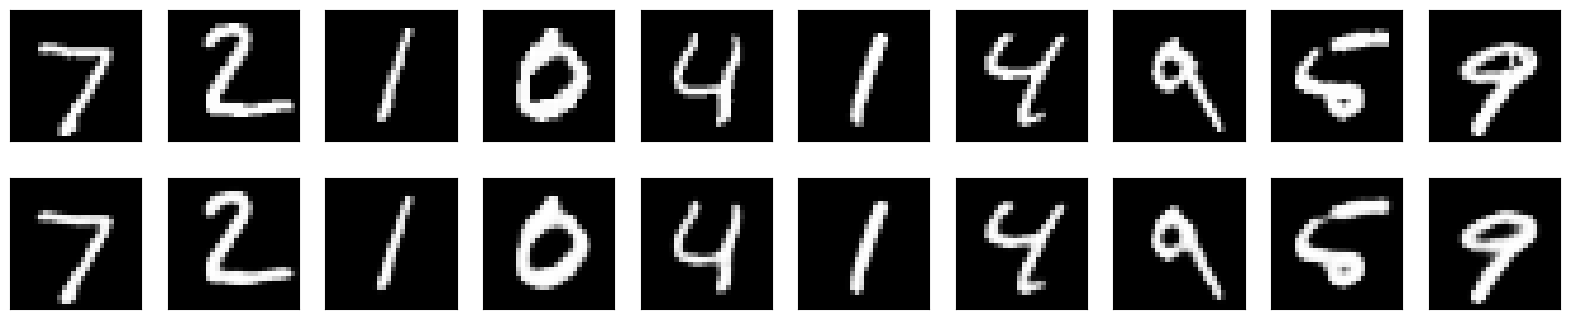

In [6]:
reconstructed = autoencoder.predict(x_test)

# Visualize results
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

Lets add random noise to the dataset and train the autoencoder to denoise the images. The autoencoder learns to reconstruct the original images from the noisy input, which can be visualized by comparing the noisy, denoised, and original images.

### Adding Some Noise 

In [7]:
noise_factor = 0.6
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


In [8]:
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=512,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
118/118 [==============================] - 3s 24ms/step - loss: 0.1837 - val_loss: 0.1391
Epoch 2/20
118/118 [==============================] - 3s 23ms/step - loss: 0.1366 - val_loss: 0.1326
Epoch 3/20
118/118 [==============================] - 3s 23ms/step - loss: 0.1320 - val_loss: 0.1295
Epoch 4/20
118/118 [==============================] - 3s 24ms/step - loss: 0.1295 - val_loss: 0.1275
Epoch 5/20
118/118 [==============================] - 3s 24ms/step - loss: 0.1277 - val_loss: 0.1260
Epoch 6/20
118/118 [==============================] - 3s 23ms/step - loss: 0.1263 - val_loss: 0.1247
Epoch 7/20
118/118 [==============================] - 3s 25ms/step - loss: 0.1252 - val_loss: 0.1239
Epoch 8/20
118/118 [==============================] - 3s 24ms/step - loss: 0.1241 - val_loss: 0.1229
Epoch 9/20
118/118 [==============================] - 3s 25ms/step - loss: 0.1233 - val_loss: 0.1221
Epoch 10/20
118/118 [==============================] - 3s 24ms/step - loss: 0.1227 - val_lo

313/313 [==============================] - 0s 1ms/step


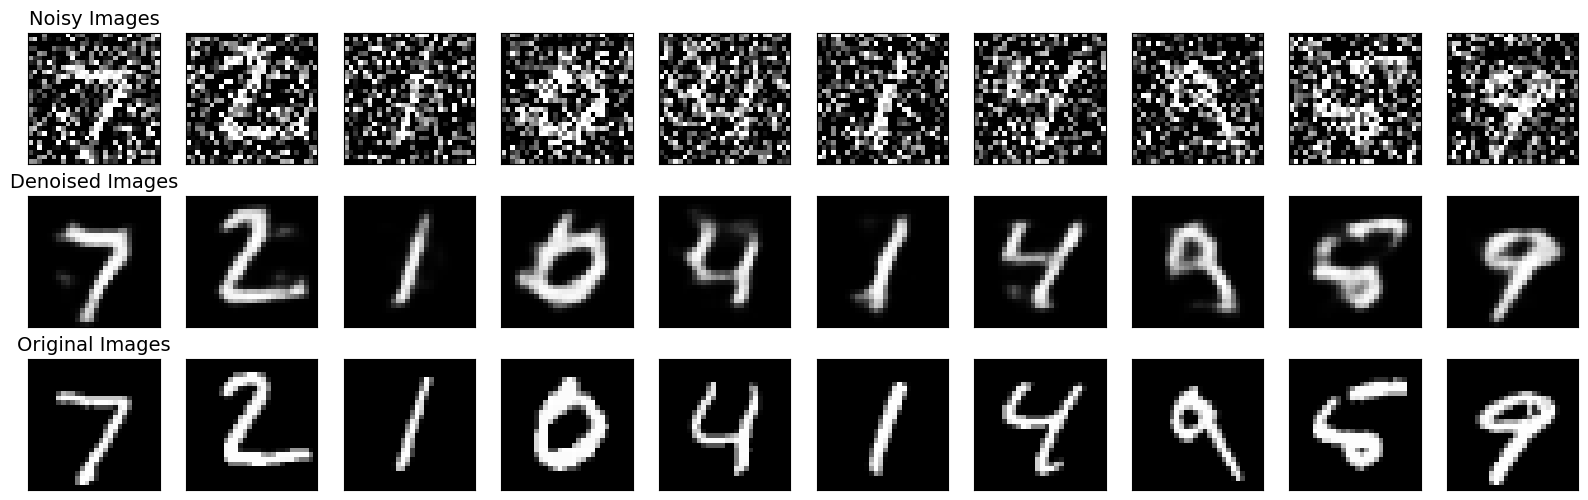

In [9]:
# Visualize the results

# Denoise the test images
reconstructed_noisy = autoencoder.predict(x_test_noisy)

n = 10  

plt.figure(figsize=(20, 6))

for i in range(n):

    # Display noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    if i == 0:
        ax.set_title("Noisy Images", fontsize=14)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display denoised images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(reconstructed_noisy[i].reshape(28, 28))
    plt.gray()
    if i == 0:
        ax.set_title("Denoised Images", fontsize=14)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display original images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    if i == 0:
        ax.set_title("Original Images", fontsize=14)

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

### Fine tuning
training for 20 more epochs

In [10]:
# Unfreeze the top layers of the encoder
for layer in autoencoder.layers: 
    layer.trainable = True 

# Compile the model again
autoencoder.compile(optimizer='adam', loss='binary_crossentropy') 

# Train the model again
autoencoder.fit(x_train_noisy, x_train,  
                initial_epoch=20,
                epochs=40,  
                batch_size=256,  
                shuffle=True,  
                validation_data=(x_test_noisy, x_test))

Epoch 21/40
235/235 [==============================] - 4s 14ms/step - loss: 0.1190 - val_loss: 0.1170
Epoch 22/40
235/235 [==============================] - 3s 13ms/step - loss: 0.1175 - val_loss: 0.1163
Epoch 23/40
235/235 [==============================] - 3s 14ms/step - loss: 0.1169 - val_loss: 0.1158
Epoch 24/40
235/235 [==============================] - 3s 13ms/step - loss: 0.1162 - val_loss: 0.1151
Epoch 25/40
235/235 [==============================] - 3s 13ms/step - loss: 0.1156 - val_loss: 0.1149
Epoch 26/40
235/235 [==============================] - 3s 14ms/step - loss: 0.1149 - val_loss: 0.1139
Epoch 27/40
235/235 [==============================] - 3s 14ms/step - loss: 0.1143 - val_loss: 0.1133
Epoch 28/40
235/235 [==============================] - 3s 14ms/step - loss: 0.1138 - val_loss: 0.1129
Epoch 29/40
235/235 [==============================] - 3s 14ms/step - loss: 0.1134 - val_loss: 0.1125
Epoch 30/40
235/235 [==============================] - 3s 14ms/step - loss: 0.1131

Results after training for 20 more epochs

313/313 [==============================] - 1s 1ms/step


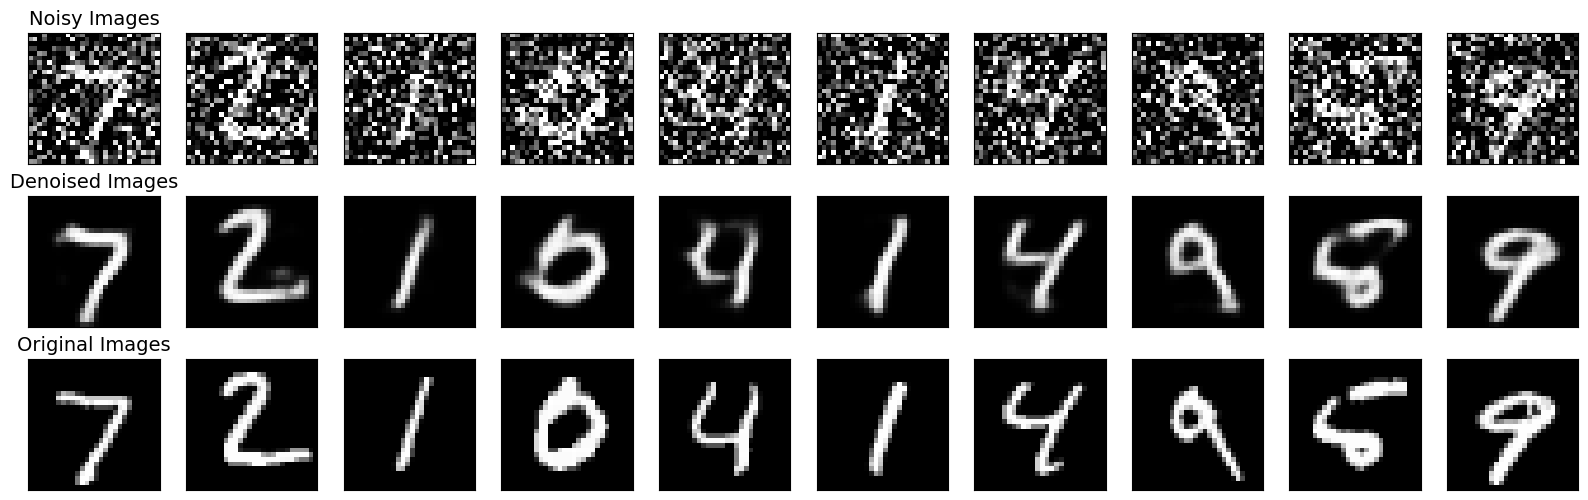

In [11]:
reconstructed_noisy = autoencoder.predict(x_test_noisy)
n = 10  
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    if i == 0:
        ax.set_title("Noisy Images", fontsize=14)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # Display denoised images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(reconstructed_noisy[i].reshape(28, 28))
    plt.gray()
    if i == 0:
        ax.set_title("Denoised Images", fontsize=14)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display original images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    if i == 0:
        ax.set_title("Original Images", fontsize=14)

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

### Visualizing Intermediate Representations 

In [12]:
# Extract encoder model
encoder = tf.keras.models.Model(
    inputs=autoencoder.input,
    outputs=encoded
)

encoder.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 16)        4624      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 16)         0         
 2D)                                                             
                                                                 
Total params: 4,944
Trainable params: 4,944
Non-trainable p

In [13]:
# Get encoded representations
encoded_imgs = encoder.predict(x_test_noisy)

print("Encoded shape:", encoded_imgs.shape)


313/313 [==============================] - 0s 1ms/step
Encoded shape: (10000, 7, 7, 16)


In [14]:
encoded_flat = encoded_imgs.reshape(encoded_imgs.shape[0], -1)

print("Flattened encoded shape:", encoded_flat.shape)


Flattened encoded shape: (10000, 784)


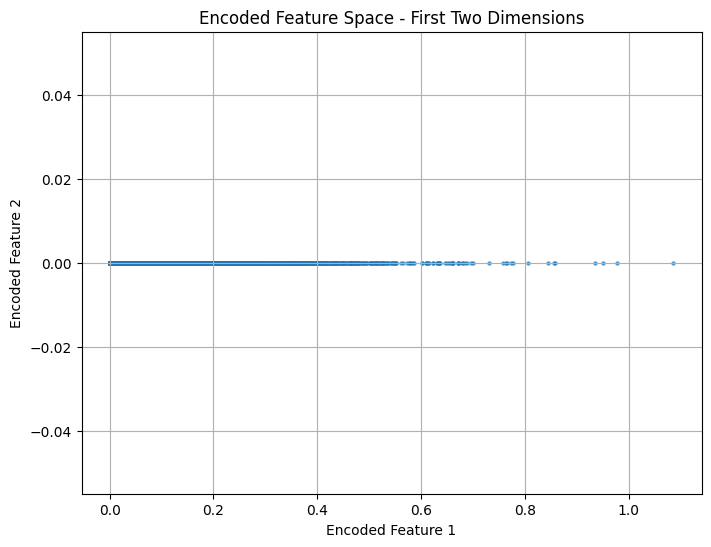

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(
    encoded_flat[:, 0],
    encoded_flat[:, 1],
    s=5,
    alpha=0.6
)

plt.xlabel("Encoded Feature 1")
plt.ylabel("Encoded Feature 2")
plt.title("Encoded Feature Space - First Two Dimensions")
plt.grid(True)
plt.show()


### Final Result

After additional training, Model showed further improvement, suggesting enhanced reconstruction quality and improved model convergence.
Further improvements may still be possible through architectural enhancements, tuning hyperparameters, or experimenting with different loss functions.